# SigLIP Text Feature Clustering for BIM Objects

KMeans clustering on SigLIP **text** embeddings from `siglip2_large_16_512_text/`.
Single variant (no colored/colorless), with PCA reduction and handcrafted feature fusion.

All evaluation uses **19 merged types**.

In [ ]:
import sys, json, warnings
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import trimesh
from pathlib import Path
from scipy.stats import entropy
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
# Load dataset + SigLIP text features + handcrafted features
df_all = pd.read_parquet('../../processed_data/features/train_features.parquet')
with open('../../data/annotated_subset.json') as f:
    annotated = json.load(f)
annotated_gids = set(d['GlobalId'] for d in annotated)
df = df_all[df_all['GlobalId'].isin(annotated_gids)].copy().reset_index(drop=True)

text_dir = Path('../../processed_data/rendered_features/siglip2_large_16_512_text')
mesh_dir = Path('../../processed_data/meshes/train')

def load_features(feat_dir, gids):
    features, matched_gids = [], []
    for gid in gids:
        path = feat_dir / f'{gid}.npy'
        if path.exists():
            features.append(np.load(path))
            matched_gids.append(gid)
    return np.stack(features), matched_gids

X_text, gids_text = load_features(text_dir, df['GlobalId'].values)
df_model = df[df['GlobalId'].isin(gids_text)].copy().reset_index(drop=True)
idx_t = {g: i for i, g in enumerate(gids_text)}
X_text = np.stack([X_text[idx_t[g]] for g in df_model['GlobalId']])

# Quick sanity check: are all features identical?
if np.allclose(X_text[0], X_text[1]) and np.allclose(X_text[0], X_text[100]):
    print('WARNING: All text features appear identical! Extraction may be broken.')
else:
    print('Text features look varied (good).')

# Compute handcrafted 9 features
BASELINE = ['Length', 'CrossSectionArea', 'Volume', 'NumVertices']
Z_AXIS = np.array([0, 0, 1])
ref_dirs = np.array(trimesh.creation.icosphere(subdivisions=1).vertices)
ref_dirs = ref_dirs / np.linalg.norm(ref_dirs, axis=1, keepdims=True)
N_BINS = len(ref_dirs)

engineered = []
for gid in df_model['GlobalId'].values:
    mesh_path = mesh_dir / f'{gid}.obj'
    if not mesh_path.exists():
        engineered.append(None); continue
    mesh = trimesh.load(mesh_path, force='mesh', process=False)
    verts = np.array(mesh.vertices)
    if len(verts) < 3:
        engineered.append(None); continue
    pca = PCA(n_components=3).fit(verts)
    pc1_z = abs(np.dot(pca.components_[0], Z_AXIS))
    pc3_z = abs(np.dot(pca.components_[2], Z_AXIS))
    extents = np.sqrt(pca.explained_variance_)
    cs_ratio = extents[2] / extents[1] if extents[1] > 1e-8 else 0.0
    normals, areas = mesh.face_normals, mesh.area_faces
    if len(normals) > 0 and len(areas) > 0:
        dots = normals @ ref_dirs.T
        hist = np.bincount(dots.argmax(axis=1), weights=areas, minlength=N_BINS)
        hist = hist / hist.sum()
        norm_ent = entropy(hist) / np.log(N_BINS)
        horiz_frac = areas[np.abs(normals @ Z_AXIS) > 0.9].sum() / areas.sum()
    else:
        norm_ent, horiz_frac = 0.0, 0.0
    engineered.append({'pc1_z': pc1_z, 'pc3_z': pc3_z, 'cs_aspect_ratio': cs_ratio,
                       'normal_entropy': norm_ent, 'horiz_frac': horiz_frac})

valid_mask = np.array([e is not None for e in engineered])
df_valid = df_model[valid_mask].reset_index(drop=True)
X_text = X_text[valid_mask]
df_eng = pd.DataFrame([e for e in engineered if e is not None])
X_handcrafted = np.hstack([
    np.log1p(df_valid[BASELINE].clip(lower=0).values),
    df_eng[['pc1_z', 'pc3_z', 'cs_aspect_ratio', 'normal_entropy', 'horiz_frac']].values
])

# Merge types (24 → 19)
TYPE_MAP = {
    'IfcWall': 'Wall', 'IfcWallStandardCase': 'Wall',
    'IfcFurniture': 'Furniture', 'IfcFurnishingElement': 'Furniture',
    'IfcSystemFurnitureElement': 'Furniture',
    'IfcDistributionFlowElement': 'MEP', 'IfcFlowTerminal': 'MEP',
    'IfcStair': 'Stair', 'IfcStairFlight': 'Stair',
}
ifc_types = np.array([TYPE_MAP.get(t, t) for t in df_valid['IfcType'].values])

print(f'{len(df_valid)} objects, {len(set(ifc_types))} merged types')
print(f'Text: {X_text.shape}, Handcrafted: {X_handcrafted.shape}')

Text features look varied (good).
1845 objects, 19 merged types
Text: (1845, 1, 1024), Handcrafted: (1845, 9)


In [6]:
X_text = X_text.squeeze(1)
print(X_text.shape)

ValueError: cannot select an axis to squeeze out which has size not equal to one

In [ ]:
SEEDS = list(range(42, 52))
PCA_DIMS = [2, 4, 8, 16, 32]
K_VALUES = [4, 8, 16, 24, 32]

def compute_purity(labels, true_labels):
    return sum(pd.Series(true_labels[labels == c]).value_counts().iloc[0]
               for c in np.unique(labels)) / len(labels)

def eval_kmeans(X, labels, k=24, seeds=SEEDS):
    metrics = {'purity': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}
    for s in seeds:
        lab = MiniBatchKMeans(k, batch_size=1024, n_init='auto', random_state=s).fit_predict(X)
        metrics['purity'].append(compute_purity(lab, labels))
        metrics['silhouette'].append(silhouette_score(X, lab))
        metrics['davies_bouldin'].append(davies_bouldin_score(X, lab))
        metrics['calinski_harabasz'].append(calinski_harabasz_score(X, lab))
    return {k_: (np.mean(v), np.std(v)) for k_, v in metrics.items()}

def per_type_purity(lab, true_labels):
    cluster_dominant = {}
    for c in np.unique(lab):
        mask = lab == c
        counts = pd.Series(true_labels[mask]).value_counts()
        cluster_dominant[c] = counts.index[0]
    type_purity = {}
    for t in np.unique(true_labels):
        t_mask = true_labels == t
        t_objects = t_mask.sum()
        correct = sum(1 for i in np.where(t_mask)[0] if cluster_dominant[lab[i]] == t)
        type_purity[t] = correct / t_objects
    return type_purity

def title_metrics(X, lab, labels):
    p = compute_purity(lab, labels)
    s = silhouette_score(X, lab)
    db = davies_bouldin_score(X, lab)
    return f'Purity={p:.3f}  Sil={s:.3f}  DB={db:.2f}'

# Precompute PCA projections
feat_dim = X_text.shape[1]
pca_text = {}
for d in PCA_DIMS:
    pca_text[d] = PCA(n_components=d, random_state=42).fit_transform(X_text)
pca_text[feat_dim] = X_text
all_dims = PCA_DIMS + [feat_dim]
dim_labels = [str(d) for d in all_dims]

print('Ready. PCA variance retained (text):')
for d in PCA_DIMS:
    pca_obj = PCA(n_components=d, random_state=42).fit(X_text)
    print(f'  PCA-{d}: {pca_obj.explained_variance_ratio_.sum():.1%}')

## 1. PCA × k Purity Grid (SigLIP Text only)

In [9]:
# Sweep PCA dims × k for text and handcrafted baseline
grid_text = np.zeros((len(all_dims), len(K_VALUES)))
for i, d in enumerate(all_dims):
    for j, k in enumerate(K_VALUES):
        grid_text[i, j] = eval_kmeans(pca_text[d], ifc_types, k=k)['purity'][0]
        print(f'  PCA-{d:>4} k={k:>2}  text={grid_text[i,j]:.3f}')

hc_purity = {k: eval_kmeans(X_handcrafted, ifc_types, k=k)['purity'][0] for k in K_VALUES}
print(f'\nHandcrafted: {" ".join(f"k={k}:{v:.3f}" for k,v in hc_purity.items())}')

  PCA-   2 k= 4  text=0.140
  PCA-   2 k= 8  text=0.142
  PCA-   2 k=16  text=0.152
  PCA-   2 k=24  text=0.162
  PCA-   2 k=32  text=0.169
  PCA-   4 k= 4  text=0.140
  PCA-   4 k= 8  text=0.141
  PCA-   4 k=16  text=0.150
  PCA-   4 k=24  text=0.162
  PCA-   4 k=32  text=0.172
  PCA-   8 k= 4  text=0.141
  PCA-   8 k= 8  text=0.142
  PCA-   8 k=16  text=0.153
  PCA-   8 k=24  text=0.159
  PCA-   8 k=32  text=0.166
  PCA-  16 k= 4  text=0.141
  PCA-  16 k= 8  text=0.143
  PCA-  16 k=16  text=0.152
  PCA-  16 k=24  text=0.169
  PCA-  16 k=32  text=0.178
  PCA-  32 k= 4  text=0.143
  PCA-  32 k= 8  text=0.147
  PCA-  32 k=16  text=0.157
  PCA-  32 k=24  text=0.172
  PCA-  32 k=32  text=0.180
  PCA-1024 k= 4  text=0.140
  PCA-1024 k= 8  text=0.144
  PCA-1024 k=16  text=0.155
  PCA-1024 k=24  text=0.165
  PCA-1024 k=32  text=0.174

Handcrafted: k=4:0.265 k=8:0.375 k=16:0.516 k=24:0.595 k=32:0.633


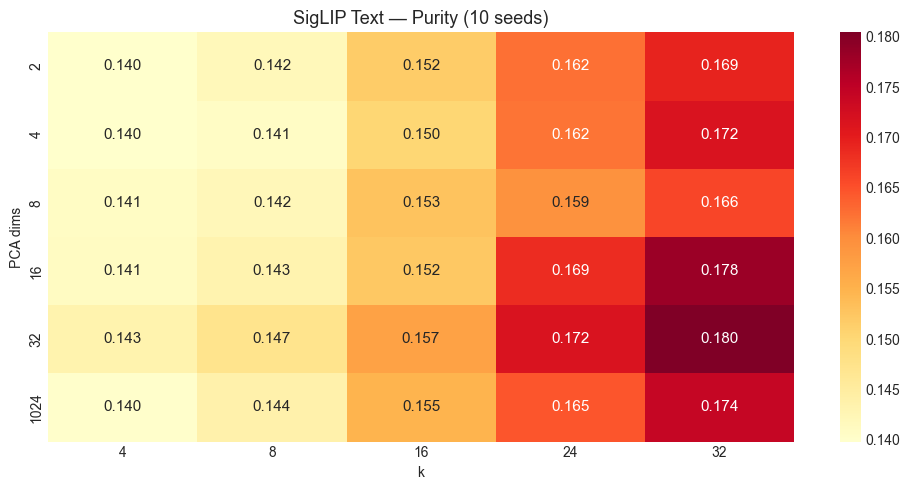

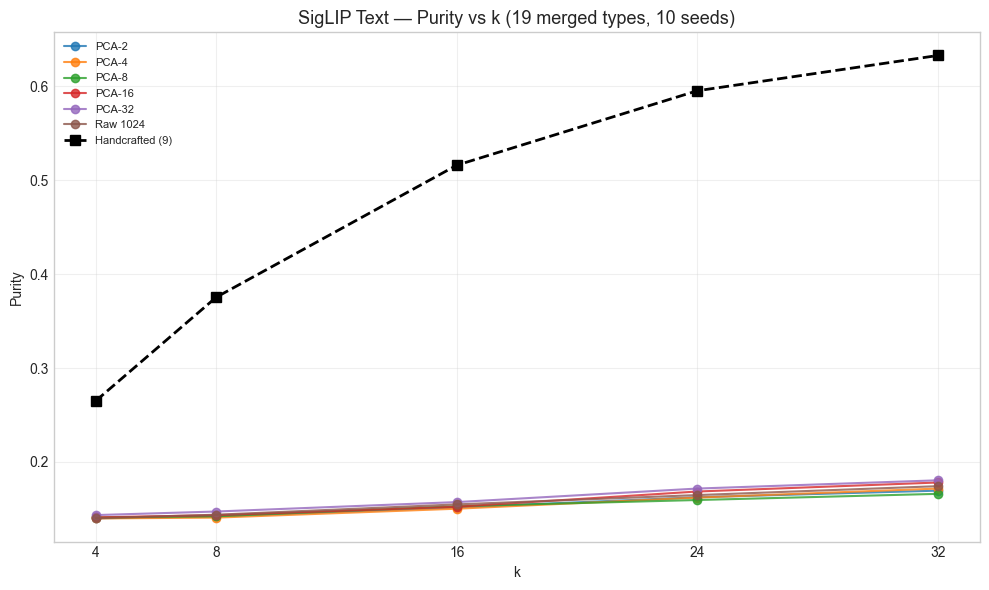

In [10]:
# Heatmap: PCA × k
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(grid_text, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=[str(k) for k in K_VALUES], yticklabels=dim_labels,
            ax=ax, annot_kws={'size': 11})
ax.set_xlabel('k'); ax.set_ylabel('PCA dims')
ax.set_title('SigLIP Text — Purity (10 seeds)', fontsize=13)
plt.tight_layout(); plt.show()

# Line plot: purity vs k
fig, ax = plt.subplots(figsize=(10, 6))
for i, d in enumerate(all_dims):
    label = f'PCA-{d}' if d != feat_dim else f'Raw {feat_dim}'
    ax.plot(K_VALUES, grid_text[i], 'o-', label=label, alpha=0.8)
ax.plot(K_VALUES, [hc_purity[k] for k in K_VALUES], 's--', color='black',
        linewidth=2, markersize=7, label='Handcrafted (9)')
ax.set_xlabel('k'); ax.set_ylabel('Purity')
ax.set_title('SigLIP Text — Purity vs k (19 merged types, 10 seeds)', fontsize=13)
ax.legend(fontsize=8); ax.set_xticks(K_VALUES); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Best PCA Config — Cluster–Type Heatmap

In [ ]:
# Best (dim, k) — heatmap
best_idx = np.unravel_index(grid_text.argmax(), grid_text.shape)
best_dim, best_k = all_dims[best_idx[0]], K_VALUES[best_idx[1]]
print(f'Text: best PCA-{best_dim}, k={best_k} → purity={grid_text[best_idx]:.3f}')

X_best = pca_text[best_dim]
lab = MiniBatchKMeans(best_k, batch_size=1024, n_init='auto', random_state=42).fit_predict(X_best)
ct = pd.crosstab(pd.Series(lab, name='Cluster'),
                 pd.Series(ifc_types, name='Type'), normalize='index')
ct = ct.reindex(pd.Series(lab).value_counts().index)

fig, ax = plt.subplots(figsize=(16, max(8, best_k * 0.35)))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, annot_kws={'size': 6})
ax.set_title(f'SigLIP Text PCA-{best_dim}, k={best_k} — {title_metrics(X_best, lab, ifc_types)}', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(); plt.show()

## 3. SigLIP Text PCA + Handcrafted Fusion — All Combos

In [12]:
# PCA × k grid for Text + Handcrafted fusion
grid_text_hc = np.zeros((len(all_dims), len(K_VALUES)))
for i, d in enumerate(all_dims):
    X_fused = np.hstack([pca_text[d], X_handcrafted])
    for j, k in enumerate(K_VALUES):
        grid_text_hc[i, j] = eval_kmeans(X_fused, ifc_types, k=k)['purity'][0]
        print(f'  PCA-{d:>4}+HC k={k:>2}  text+hc={grid_text_hc[i,j]:.3f}')

  PCA-   2+HC k= 4  text+hc=0.262
  PCA-   2+HC k= 8  text+hc=0.325
  PCA-   2+HC k=16  text+hc=0.409
  PCA-   2+HC k=24  text+hc=0.466
  PCA-   2+HC k=32  text+hc=0.507
  PCA-   4+HC k= 4  text+hc=0.178
  PCA-   4+HC k= 8  text+hc=0.230
  PCA-   4+HC k=16  text+hc=0.308
  PCA-   4+HC k=24  text+hc=0.362
  PCA-   4+HC k=32  text+hc=0.406
  PCA-   8+HC k= 4  text+hc=0.147
  PCA-   8+HC k= 8  text+hc=0.161
  PCA-   8+HC k=16  text+hc=0.202
  PCA-   8+HC k=24  text+hc=0.242
  PCA-   8+HC k=32  text+hc=0.278
  PCA-  16+HC k= 4  text+hc=0.144
  PCA-  16+HC k= 8  text+hc=0.152
  PCA-  16+HC k=16  text+hc=0.176
  PCA-  16+HC k=24  text+hc=0.199
  PCA-  16+HC k=32  text+hc=0.221
  PCA-  32+HC k= 4  text+hc=0.147
  PCA-  32+HC k= 8  text+hc=0.155
  PCA-  32+HC k=16  text+hc=0.175
  PCA-  32+HC k=24  text+hc=0.188
  PCA-  32+HC k=32  text+hc=0.209
  PCA-1024+HC k= 4  text+hc=0.140
  PCA-1024+HC k= 8  text+hc=0.143
  PCA-1024+HC k=16  text+hc=0.151
  PCA-1024+HC k=24  text+hc=0.168
  PCA-1024+HC 

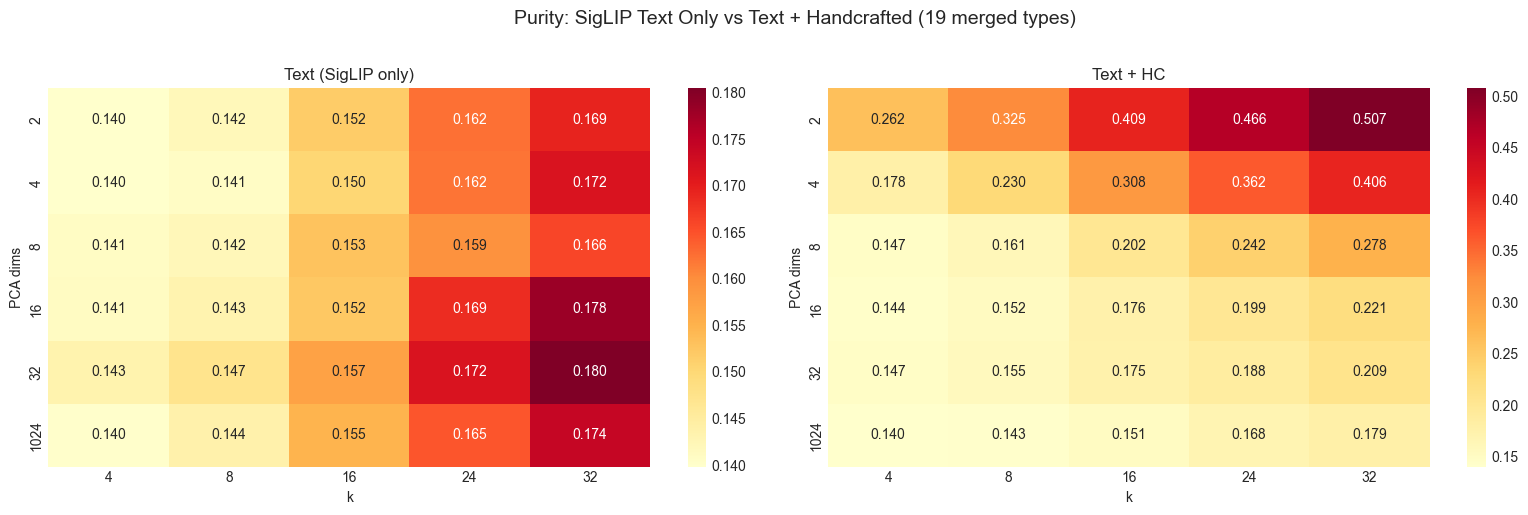

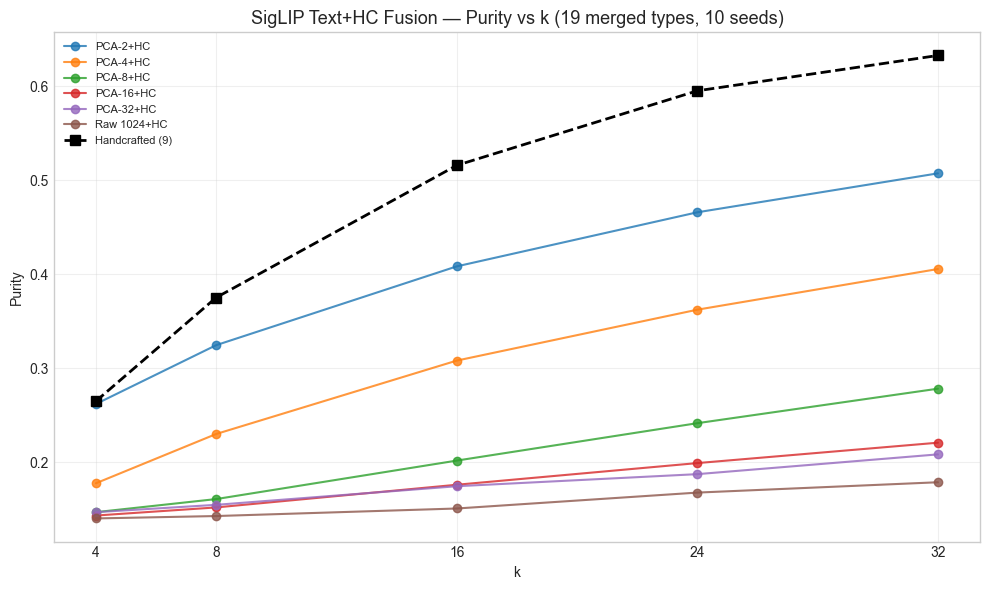

In [13]:
# Heatmaps: Text-only vs Text+HC (2 panels)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, grid, title in [(axes[0], grid_text, 'Text (SigLIP only)'),
                         (axes[1], grid_text_hc, 'Text + HC')]:
    sns.heatmap(grid, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=[str(k) for k in K_VALUES], yticklabels=dim_labels,
                ax=ax, annot_kws={'size': 10})
    ax.set_xlabel('k'); ax.set_ylabel('PCA dims')
    ax.set_title(title, fontsize=12)
plt.suptitle('Purity: SigLIP Text Only vs Text + Handcrafted (19 merged types)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Line plot: Text+HC fusion vs handcrafted baseline
fig, ax = plt.subplots(figsize=(10, 6))
for i, d in enumerate(all_dims):
    label = f'PCA-{d}+HC' if d != feat_dim else f'Raw {feat_dim}+HC'
    ax.plot(K_VALUES, grid_text_hc[i], 'o-', label=label, alpha=0.8)
ax.plot(K_VALUES, [hc_purity[k] for k in K_VALUES], 's--', color='black',
        linewidth=2, markersize=7, label='Handcrafted (9)')
ax.set_xlabel('k'); ax.set_ylabel('Purity')
ax.set_title('SigLIP Text+HC Fusion — Purity vs k (19 merged types, 10 seeds)', fontsize=13)
ax.legend(fontsize=8); ax.set_xticks(K_VALUES); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Best Overall Config — Detailed Analysis

In [14]:
# Find global best across both grids
all_grids = [
    (grid_text, pca_text, 'Text', False),
    (grid_text_hc, pca_text, 'Text+HC', True),
]
best_hc_k = max(hc_purity, key=hc_purity.get)
print(f'Handcrafted best: k={best_hc_k} → purity={hc_purity[best_hc_k]:.3f}\n')

best_configs = []
for grid, pca_dict, label, fused in all_grids:
    idx = np.unravel_index(grid.argmax(), grid.shape)
    d, k = all_dims[idx[0]], K_VALUES[idx[1]]
    X_feat = np.hstack([pca_dict[d], X_handcrafted]) if fused else pca_dict[d]
    best_configs.append((label, d, k, grid[idx], X_feat))
    print(f'{label}: PCA-{d}, k={k} → purity={grid[idx]:.3f} ({X_feat.shape[1]} dims)')

# Sort by purity descending
best_configs.sort(key=lambda x: x[3], reverse=True)
print(f'\nBest overall: {best_configs[0][0]} PCA-{best_configs[0][1]} k={best_configs[0][2]}')

Handcrafted best: k=32 → purity=0.633

Text: PCA-32, k=32 → purity=0.180 (32 dims)
Text+HC: PCA-2, k=32 → purity=0.507 (11 dims)

Best overall: Text+HC PCA-2 k=32


In [ ]:
# Cluster–type heatmaps for best configs + handcrafted
plot_configs = list(best_configs)
plot_configs.append(('Handcrafted', 9, best_hc_k, hc_purity[best_hc_k], X_handcrafted))

for label, d, k, pur, X in plot_configs:
    lab = MiniBatchKMeans(k, batch_size=1024, n_init='auto', random_state=42).fit_predict(X)
    ct = pd.crosstab(pd.Series(lab, name='Cluster'),
                     pd.Series(ifc_types, name='Type'), normalize='index')
    ct = ct.reindex(pd.Series(lab).value_counts().index)

    fig, ax = plt.subplots(figsize=(16, max(8, k * 0.35)))
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
                annot_kws={'size': 6 if k > 24 else 7})
    ax.set_title(f'{label} (d={d}), k={k} — {title_metrics(X, lab, ifc_types)}', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout(); plt.show()

In [ ]:
# Per-type purity comparison: best configs + handcrafted
all_merged = sorted(set(ifc_types))
tp_results = {}
for label, d, k, pur, X in plot_configs:
    lab = MiniBatchKMeans(k, batch_size=1024, n_init='auto', random_state=42).fit_predict(X)
    tp_results[f'{label} k={k}'] = per_type_purity(lab, ifc_types)

tp_names = list(tp_results.keys())
df_tp = pd.DataFrame({n: [tp_results[n].get(t, 0) for t in all_merged]
                       for n in tp_names}, index=all_merged)
df_tp.index = df_tp.index.str.replace('Ifc', '')
df_tp = df_tp.sort_values(tp_names[0], ascending=False)

# Absolute purity
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_tp, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Per-Type Purity — Best Configs (19 merged types, seed=42)', fontsize=12)
ax.set_xlabel('Config'); ax.set_ylabel('Type')
plt.tight_layout(); plt.show()

# Delta vs handcrafted
hc_col = tp_names[-1]  # Handcrafted is last
df_delta = pd.DataFrame(index=df_tp.index)
for n in tp_names[:-1]:
    df_delta[n] = df_tp[n] - df_tp[hc_col]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_delta, annot=True, fmt='+.02f', cmap='RdYlGn', vmin=-0.5, vmax=0.5,
            center=0, ax=ax, annot_kws={'size': 9})
ax.set_title(f'Per-Type Purity Δ vs {hc_col} (seed=42)', fontsize=12)
ax.set_xlabel('Config'); ax.set_ylabel('Type')
plt.tight_layout(); plt.show()

---

# SigLIP Text v2 (`siglip2_large_16_512_text_v2`)

Same flow repeated for the v2 text embeddings.

In [17]:
# Load SigLIP Text v2 features
text_v2_dir = Path('../../processed_data/rendered_features/siglip2_large_16_512_text_v2')
X_text_v2, gids_text_v2 = load_features(text_v2_dir, df_valid['GlobalId'].values)

# Align to same valid set
gids_v2_set = set(gids_text_v2)
v2_mask = np.array([g in gids_v2_set for g in df_valid['GlobalId'].values])
idx_v2 = {g: i for i, g in enumerate(gids_text_v2)}
X_text_v2 = np.stack([X_text_v2[idx_v2[g]] for g in df_valid['GlobalId'].values[v2_mask]])

# Squeeze if needed (v1 was (N, 1, 1024))
if X_text_v2.ndim == 3:
    X_text_v2 = X_text_v2.squeeze(1)

ifc_types_v2 = ifc_types[v2_mask]
X_handcrafted_v2 = X_handcrafted[v2_mask]

# Sanity check
if len(X_text_v2) > 100 and np.allclose(X_text_v2[0], X_text_v2[1]) and np.allclose(X_text_v2[0], X_text_v2[100]):
    print('WARNING: All v2 text features appear identical! Extraction may be broken.')
else:
    print('v2 text features look varied (good).')

print(f'{len(X_text_v2)} objects, {len(set(ifc_types_v2))} merged types')
print(f'Text v2: {X_text_v2.shape}')

# Precompute PCA projections for v2
feat_dim_v2 = X_text_v2.shape[1]
pca_text_v2 = {}
for d in PCA_DIMS:
    pca_text_v2[d] = PCA(n_components=d, random_state=42).fit_transform(X_text_v2)
pca_text_v2[feat_dim_v2] = X_text_v2
all_dims_v2 = PCA_DIMS + [feat_dim_v2]
dim_labels_v2 = [str(d) for d in all_dims_v2]

print('\nPCA variance retained (text v2):')
for d in PCA_DIMS:
    pca_obj = PCA(n_components=d, random_state=42).fit(X_text_v2)
    print(f'  PCA-{d}: {pca_obj.explained_variance_ratio_.sum():.1%}')

v2 text features look varied (good).
1845 objects, 19 merged types
Text v2: (1845, 1024)

PCA variance retained (text v2):
  PCA-2: 33.8%
  PCA-4: 44.9%
  PCA-8: 54.1%
  PCA-16: 61.8%
  PCA-32: 69.3%


## 5. PCA × k Purity Grid (SigLIP Text v2 only)

In [18]:
import numpy as np
# Sweep PCA dims × k for text v2 and handcrafted baseline
grid_text_v2 = np.zeros((len(all_dims_v2), len(K_VALUES)))
for i, d in enumerate(all_dims_v2):
    for j, k in enumerate(K_VALUES):
        grid_text_v2[i, j] = eval_kmeans(pca_text_v2[d], ifc_types_v2, k=k)['purity'][0]
        print(f'  PCA-{d:>4} k={k:>2}  text_v2={grid_text_v2[i,j]:.3f}')

hc_purity_v2 = {k: eval_kmeans(X_handcrafted_v2, ifc_types_v2, k=k)['purity'][0] for k in K_VALUES}
print(f'\nHandcrafted: {" ".join(f"k={k}:{v:.3f}" for k,v in hc_purity_v2.items())}')

  PCA-   2 k= 4  text_v2=0.140
  PCA-   2 k= 8  text_v2=0.141
  PCA-   2 k=16  text_v2=0.148
  PCA-   2 k=24  text_v2=0.158
  PCA-   2 k=32  text_v2=0.167
  PCA-   4 k= 4  text_v2=0.140
  PCA-   4 k= 8  text_v2=0.141
  PCA-   4 k=16  text_v2=0.150
  PCA-   4 k=24  text_v2=0.159
  PCA-   4 k=32  text_v2=0.170
  PCA-   8 k= 4  text_v2=0.140
  PCA-   8 k= 8  text_v2=0.140
  PCA-   8 k=16  text_v2=0.151
  PCA-   8 k=24  text_v2=0.165
  PCA-   8 k=32  text_v2=0.174
  PCA-  16 k= 4  text_v2=0.140
  PCA-  16 k= 8  text_v2=0.142
  PCA-  16 k=16  text_v2=0.155
  PCA-  16 k=24  text_v2=0.164
  PCA-  16 k=32  text_v2=0.177
  PCA-  32 k= 4  text_v2=0.141
  PCA-  32 k= 8  text_v2=0.145
  PCA-  32 k=16  text_v2=0.157
  PCA-  32 k=24  text_v2=0.168
  PCA-  32 k=32  text_v2=0.178
  PCA-1024 k= 4  text_v2=0.140
  PCA-1024 k= 8  text_v2=0.140
  PCA-1024 k=16  text_v2=0.152
  PCA-1024 k=24  text_v2=0.167
  PCA-1024 k=32  text_v2=0.178

Handcrafted: k=4:0.265 k=8:0.375 k=16:0.516 k=24:0.595 k=32:0.633


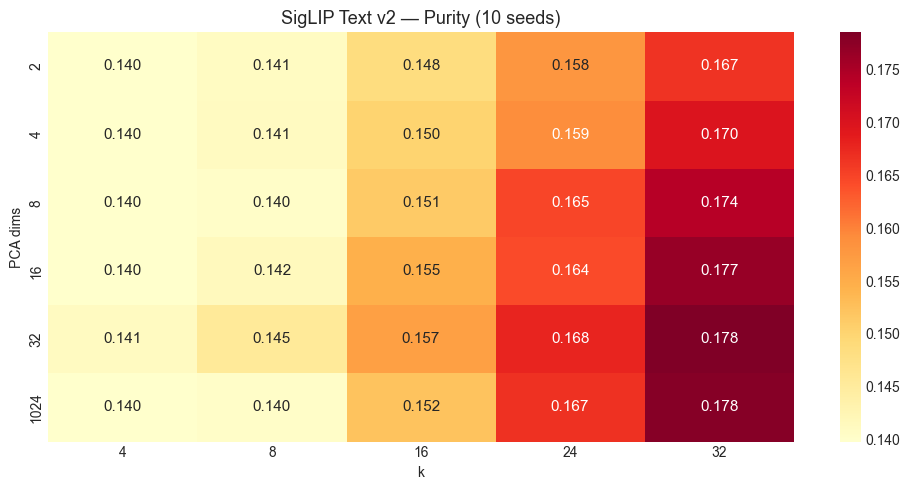

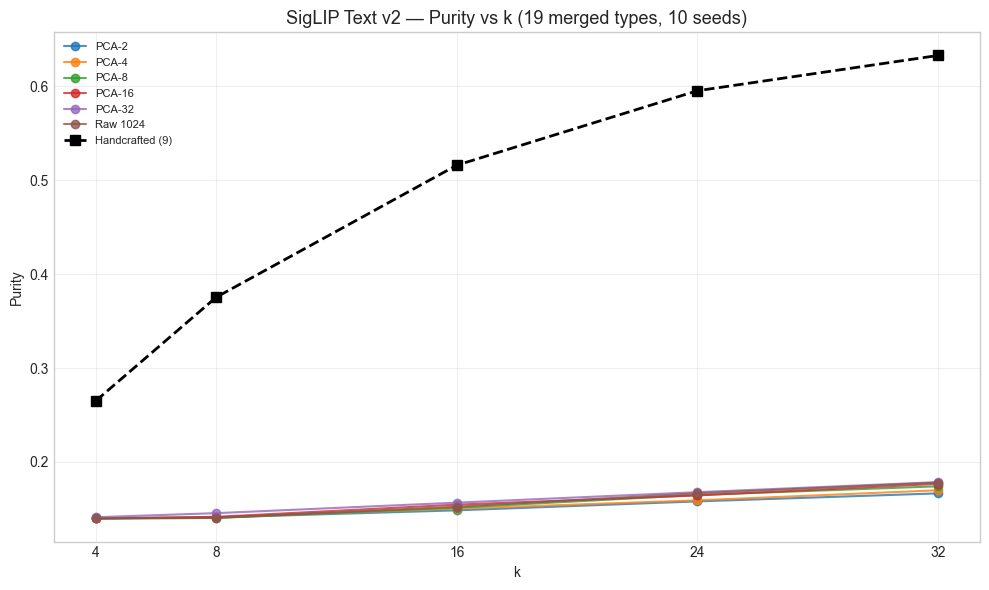

In [19]:
# Heatmap: PCA × k (v2)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(grid_text_v2, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=[str(k) for k in K_VALUES], yticklabels=dim_labels_v2,
            ax=ax, annot_kws={'size': 11})
ax.set_xlabel('k'); ax.set_ylabel('PCA dims')
ax.set_title('SigLIP Text v2 — Purity (10 seeds)', fontsize=13)
plt.tight_layout(); plt.show()

# Line plot: purity vs k (v2)
fig, ax = plt.subplots(figsize=(10, 6))
for i, d in enumerate(all_dims_v2):
    label = f'PCA-{d}' if d != feat_dim_v2 else f'Raw {feat_dim_v2}'
    ax.plot(K_VALUES, grid_text_v2[i], 'o-', label=label, alpha=0.8)
ax.plot(K_VALUES, [hc_purity_v2[k] for k in K_VALUES], 's--', color='black',
        linewidth=2, markersize=7, label='Handcrafted (9)')
ax.set_xlabel('k'); ax.set_ylabel('Purity')
ax.set_title('SigLIP Text v2 — Purity vs k (19 merged types, 10 seeds)', fontsize=13)
ax.legend(fontsize=8); ax.set_xticks(K_VALUES); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Best PCA Config v2 — Cluster–Type Heatmap

In [ ]:
# Best (dim, k) v2 — heatmap
best_idx_v2 = np.unravel_index(grid_text_v2.argmax(), grid_text_v2.shape)
best_dim_v2, best_k_v2 = all_dims_v2[best_idx_v2[0]], K_VALUES[best_idx_v2[1]]
print(f'Text v2: best PCA-{best_dim_v2}, k={best_k_v2} → purity={grid_text_v2[best_idx_v2]:.3f}')

X_best_v2 = pca_text_v2[best_dim_v2]
lab_v2 = MiniBatchKMeans(best_k_v2, batch_size=1024, n_init='auto', random_state=42).fit_predict(X_best_v2)
ct_v2 = pd.crosstab(pd.Series(lab_v2, name='Cluster'),
                     pd.Series(ifc_types_v2, name='Type'), normalize='index')
ct_v2 = ct_v2.reindex(pd.Series(lab_v2).value_counts().index)

fig, ax = plt.subplots(figsize=(16, max(8, best_k_v2 * 0.35)))
sns.heatmap(ct_v2, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, annot_kws={'size': 6})
ax.set_title(f'SigLIP Text v2 PCA-{best_dim_v2}, k={best_k_v2} — {title_metrics(X_best_v2, lab_v2, ifc_types_v2)}', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(); plt.show()

## 7. SigLIP Text v2 PCA + Handcrafted Fusion — All Combos

In [21]:
# PCA × k grid for Text v2 + Handcrafted fusion
grid_text_v2_hc = np.zeros((len(all_dims_v2), len(K_VALUES)))
for i, d in enumerate(all_dims_v2):
    X_fused = np.hstack([pca_text_v2[d], X_handcrafted_v2])
    for j, k in enumerate(K_VALUES):
        grid_text_v2_hc[i, j] = eval_kmeans(X_fused, ifc_types_v2, k=k)['purity'][0]
        print(f'  PCA-{d:>4}+HC k={k:>2}  text_v2+hc={grid_text_v2_hc[i,j]:.3f}')

  PCA-   2+HC k= 4  text_v2+hc=0.221
  PCA-   2+HC k= 8  text_v2+hc=0.309
  PCA-   2+HC k=16  text_v2+hc=0.399
  PCA-   2+HC k=24  text_v2+hc=0.451
  PCA-   2+HC k=32  text_v2+hc=0.497
  PCA-   4+HC k= 4  text_v2+hc=0.205
  PCA-   4+HC k= 8  text_v2+hc=0.249
  PCA-   4+HC k=16  text_v2+hc=0.321
  PCA-   4+HC k=24  text_v2+hc=0.367
  PCA-   4+HC k=32  text_v2+hc=0.407
  PCA-   8+HC k= 4  text_v2+hc=0.162
  PCA-   8+HC k= 8  text_v2+hc=0.172
  PCA-   8+HC k=16  text_v2+hc=0.216
  PCA-   8+HC k=24  text_v2+hc=0.260
  PCA-   8+HC k=32  text_v2+hc=0.286
  PCA-  16+HC k= 4  text_v2+hc=0.154
  PCA-  16+HC k= 8  text_v2+hc=0.159
  PCA-  16+HC k=16  text_v2+hc=0.177
  PCA-  16+HC k=24  text_v2+hc=0.206
  PCA-  16+HC k=32  text_v2+hc=0.226
  PCA-  32+HC k= 4  text_v2+hc=0.147
  PCA-  32+HC k= 8  text_v2+hc=0.162
  PCA-  32+HC k=16  text_v2+hc=0.174
  PCA-  32+HC k=24  text_v2+hc=0.184
  PCA-  32+HC k=32  text_v2+hc=0.203
  PCA-1024+HC k= 4  text_v2+hc=0.140
  PCA-1024+HC k= 8  text_v2+hc=0.141
 

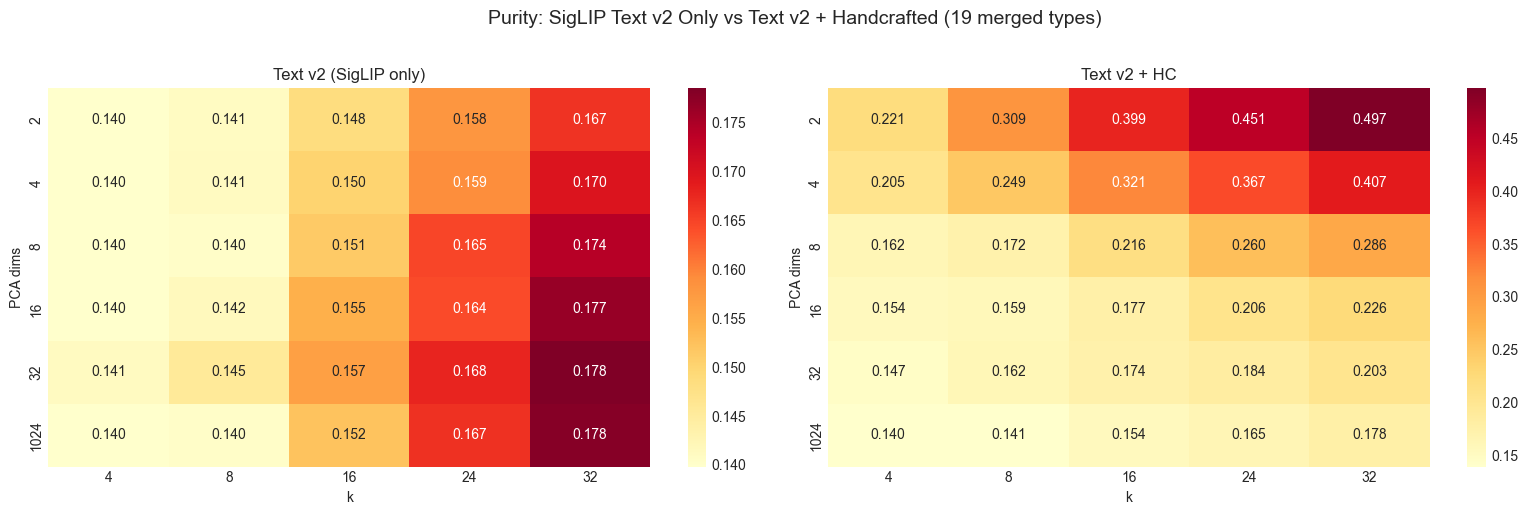

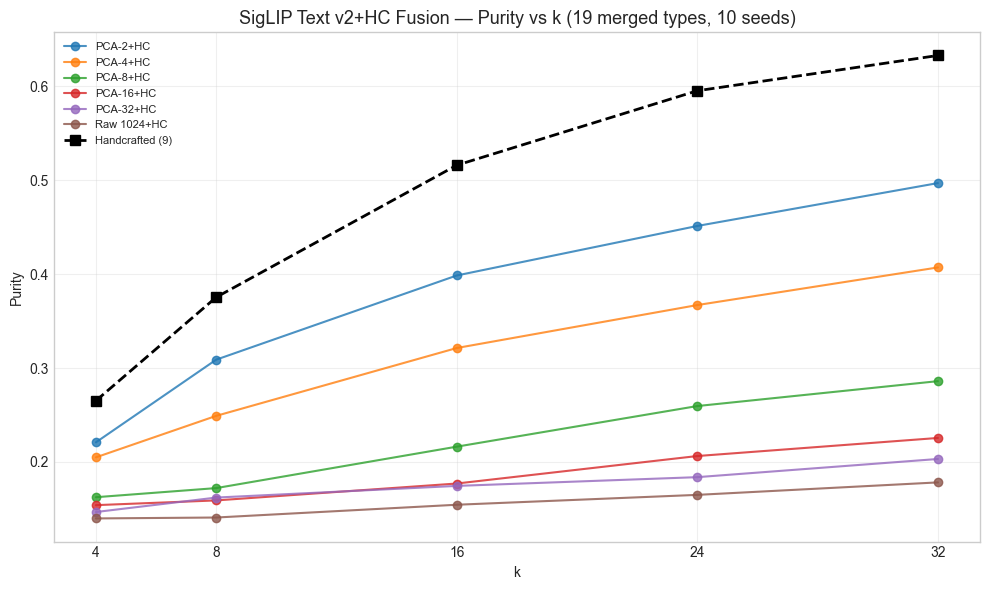

In [22]:
# Heatmaps: Text v2-only vs Text v2+HC (2 panels)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, grid, title in [(axes[0], grid_text_v2, 'Text v2 (SigLIP only)'),
                         (axes[1], grid_text_v2_hc, 'Text v2 + HC')]:
    sns.heatmap(grid, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=[str(k) for k in K_VALUES], yticklabels=dim_labels_v2,
                ax=ax, annot_kws={'size': 10})
    ax.set_xlabel('k'); ax.set_ylabel('PCA dims')
    ax.set_title(title, fontsize=12)
plt.suptitle('Purity: SigLIP Text v2 Only vs Text v2 + Handcrafted (19 merged types)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Line plot: Text v2+HC fusion vs handcrafted baseline
fig, ax = plt.subplots(figsize=(10, 6))
for i, d in enumerate(all_dims_v2):
    label = f'PCA-{d}+HC' if d != feat_dim_v2 else f'Raw {feat_dim_v2}+HC'
    ax.plot(K_VALUES, grid_text_v2_hc[i], 'o-', label=label, alpha=0.8)
ax.plot(K_VALUES, [hc_purity_v2[k] for k in K_VALUES], 's--', color='black',
        linewidth=2, markersize=7, label='Handcrafted (9)')
ax.set_xlabel('k'); ax.set_ylabel('Purity')
ax.set_title('SigLIP Text v2+HC Fusion — Purity vs k (19 merged types, 10 seeds)', fontsize=13)
ax.legend(fontsize=8); ax.set_xticks(K_VALUES); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Best Overall Config v2 — Detailed Analysis

In [23]:
# Find global best v2 across both grids
all_grids_v2 = [
    (grid_text_v2, pca_text_v2, 'Text v2', False),
    (grid_text_v2_hc, pca_text_v2, 'Text v2+HC', True),
]
best_hc_k_v2 = max(hc_purity_v2, key=hc_purity_v2.get)
print(f'Handcrafted best: k={best_hc_k_v2} → purity={hc_purity_v2[best_hc_k_v2]:.3f}\n')

best_configs_v2 = []
for grid, pca_dict, label, fused in all_grids_v2:
    idx = np.unravel_index(grid.argmax(), grid.shape)
    d, k = all_dims_v2[idx[0]], K_VALUES[idx[1]]
    X_feat = np.hstack([pca_dict[d], X_handcrafted_v2]) if fused else pca_dict[d]
    best_configs_v2.append((label, d, k, grid[idx], X_feat))
    print(f'{label}: PCA-{d}, k={k} → purity={grid[idx]:.3f} ({X_feat.shape[1]} dims)')

best_configs_v2.sort(key=lambda x: x[3], reverse=True)
print(f'\nBest overall: {best_configs_v2[0][0]} PCA-{best_configs_v2[0][1]} k={best_configs_v2[0][2]}')

Handcrafted best: k=32 → purity=0.633

Text v2: PCA-32, k=32 → purity=0.178 (32 dims)
Text v2+HC: PCA-2, k=32 → purity=0.497 (11 dims)

Best overall: Text v2+HC PCA-2 k=32


In [ ]:
# Cluster–type heatmaps for best v2 configs + handcrafted
plot_configs_v2 = list(best_configs_v2)
plot_configs_v2.append(('Handcrafted', 9, best_hc_k_v2, hc_purity_v2[best_hc_k_v2], X_handcrafted_v2))

for label, d, k, pur, X in plot_configs_v2:
    lab = MiniBatchKMeans(k, batch_size=1024, n_init='auto', random_state=42).fit_predict(X)
    ct = pd.crosstab(pd.Series(lab, name='Cluster'),
                     pd.Series(ifc_types_v2, name='Type'), normalize='index')
    ct = ct.reindex(pd.Series(lab).value_counts().index)

    fig, ax = plt.subplots(figsize=(16, max(8, k * 0.35)))
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
                annot_kws={'size': 6 if k > 24 else 7})
    ax.set_title(f'{label} (d={d}), k={k} — {title_metrics(X, lab, ifc_types_v2)}', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout(); plt.show()

In [ ]:
# Per-type purity comparison v2: best configs + handcrafted
all_merged_v2 = sorted(set(ifc_types_v2))
tp_results_v2 = {}
for label, d, k, pur, X in plot_configs_v2:
    lab = MiniBatchKMeans(k, batch_size=1024, n_init='auto', random_state=42).fit_predict(X)
    tp_results_v2[f'{label} k={k}'] = per_type_purity(lab, ifc_types_v2)

tp_names_v2 = list(tp_results_v2.keys())
df_tp_v2 = pd.DataFrame({n: [tp_results_v2[n].get(t, 0) for t in all_merged_v2]
                          for n in tp_names_v2}, index=all_merged_v2)
df_tp_v2.index = df_tp_v2.index.str.replace('Ifc', '')
df_tp_v2 = df_tp_v2.sort_values(tp_names_v2[0], ascending=False)

# Absolute purity
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_tp_v2, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Per-Type Purity — Best v2 Configs (19 merged types, seed=42)', fontsize=12)
ax.set_xlabel('Config'); ax.set_ylabel('Type')
plt.tight_layout(); plt.show()

# Delta vs handcrafted
hc_col_v2 = tp_names_v2[-1]
df_delta_v2 = pd.DataFrame(index=df_tp_v2.index)
for n in tp_names_v2[:-1]:
    df_delta_v2[n] = df_tp_v2[n] - df_tp_v2[hc_col_v2]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_delta_v2, annot=True, fmt='+.02f', cmap='RdYlGn', vmin=-0.5, vmax=0.5,
            center=0, ax=ax, annot_kws={'size': 9})
ax.set_title(f'Per-Type Purity Δ vs {hc_col_v2} (seed=42)', fontsize=12)
ax.set_xlabel('Config'); ax.set_ylabel('Type')
plt.tight_layout(); plt.show()